In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

from config import AGGREGATIONS, BENCHMARKS, RANDOM_SEED
from utils import load_dataset, seasonality_strength, plot_pool_distribution, print_summary, SOURCE_MAP
from scoring.runner import score_source, scores_path
from selection import select_source, save_selection

AGGREGATION = "10min"
BENCHMARK = "SEASON"
AGG_PARAMS = AGGREGATIONS[AGGREGATION]
BENCH_PARAMS = BENCHMARKS[BENCHMARK]
STEP_MINUTES = 24 * 60 // AGG_PARAMS["daily_period"]

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

print(f"Benchmark: {BENCHMARK}")
print(f"Aggregation: {AGGREGATION}")
print(f"Threshold: {BENCH_PARAMS['metric_col']} {BENCH_PARAMS['metric_op']} {BENCH_PARAMS['threshold']}")
print(f"Sparsity min: {BENCH_PARAMS['sparsity_min']}")
print(f"Sample size: {BENCH_PARAMS['sample_size']} | Seed: {RANDOM_SEED}")

Benchmark: SEASON
Aggregation: 10min
Threshold: max_strength >= 0.7
Sparsity min: 0.4
Sample size: 25 | Seed: 42


## 1 — Scoring

Compute seasonality scores (daily + weekly STL strength) for each source level.
If a score file already exists it is loaded from disk; otherwise `score_source` runs the full computation.

In [2]:
sources = BENCH_PARAMS["levels"]
scores = {}

for source in sources:
    path = scores_path(AGGREGATION, BENCHMARK, source)
    if os.path.exists(path):
        print(f"Loading existing scores: {path}")
        scores[source] = pd.read_csv(path)
    else:
        print(f"Computing scores for {source}...")
        scores[source] = score_source(BENCHMARK, source, aggregation=AGGREGATION)

for source, df in scores.items():
    print(f"\n{source}: {len(df)} series scored")
    display(df.describe().round(3))

Loading existing scores: scores/10min/SEASON_institutions.csv
Loading existing scores: scores/10min/SEASON_subnets.csv
Loading existing scores: scores/10min/SEASON_ips.csv

institutions: 283 series scored


,id_institution,ratio_active,strength_daily,strength_weekly,max_strength
count,283.000,283.000,266.000,266.000,266.000
mean,142.233,0.916,0.539,0.582,0.585
std,82.480,0.216,0.118,0.137,0.136
min,0.000,0.000,0.336,0.331,0.350
25%,71.500,0.978,0.442,0.475,0.475
50%,142.000,0.999,0.549,0.603,0.603
75%,213.500,1.000,0.630,0.691,0.693
max,284.000,1.000,0.869,0.850,0.869



subnets: 548 series scored


,id_institution_subnet,ratio_active,strength_daily,strength_weekly,max_strength
count,548.000,548.000,468.000,468.000,468.000
mean,273.500,0.813,0.486,0.518,0.520
std,158.338,0.322,0.124,0.145,0.145
min,0.000,0.000,0.336,0.328,0.345
25%,136.750,0.788,0.364,0.371,0.373
50%,273.500,0.994,0.472,0.495,0.500
75%,410.250,1.000,0.584,0.642,0.646
max,547.000,1.000,0.857,0.846,0.857



ips: 1000 series scored


,id_ip,ratio_active,strength_daily,strength_weekly,max_strength
count,1000.000,1000.000,150.000,150.000,150.000
mean,860461.454,0.170,0.393,0.408,0.410
std,679140.522,0.265,0.086,0.098,0.098
min,11.000,0.003,0.326,0.330,0.345
25%,266825.500,0.019,0.350,0.359,0.360
50%,635072.500,0.055,0.358,0.369,0.371
75%,1629478.250,0.155,0.392,0.406,0.410
max,2044888.000,1.000,0.795,0.864,0.864


## 2 — Score distributions

Histogram of `max_strength` per level with the selection threshold overlaid.

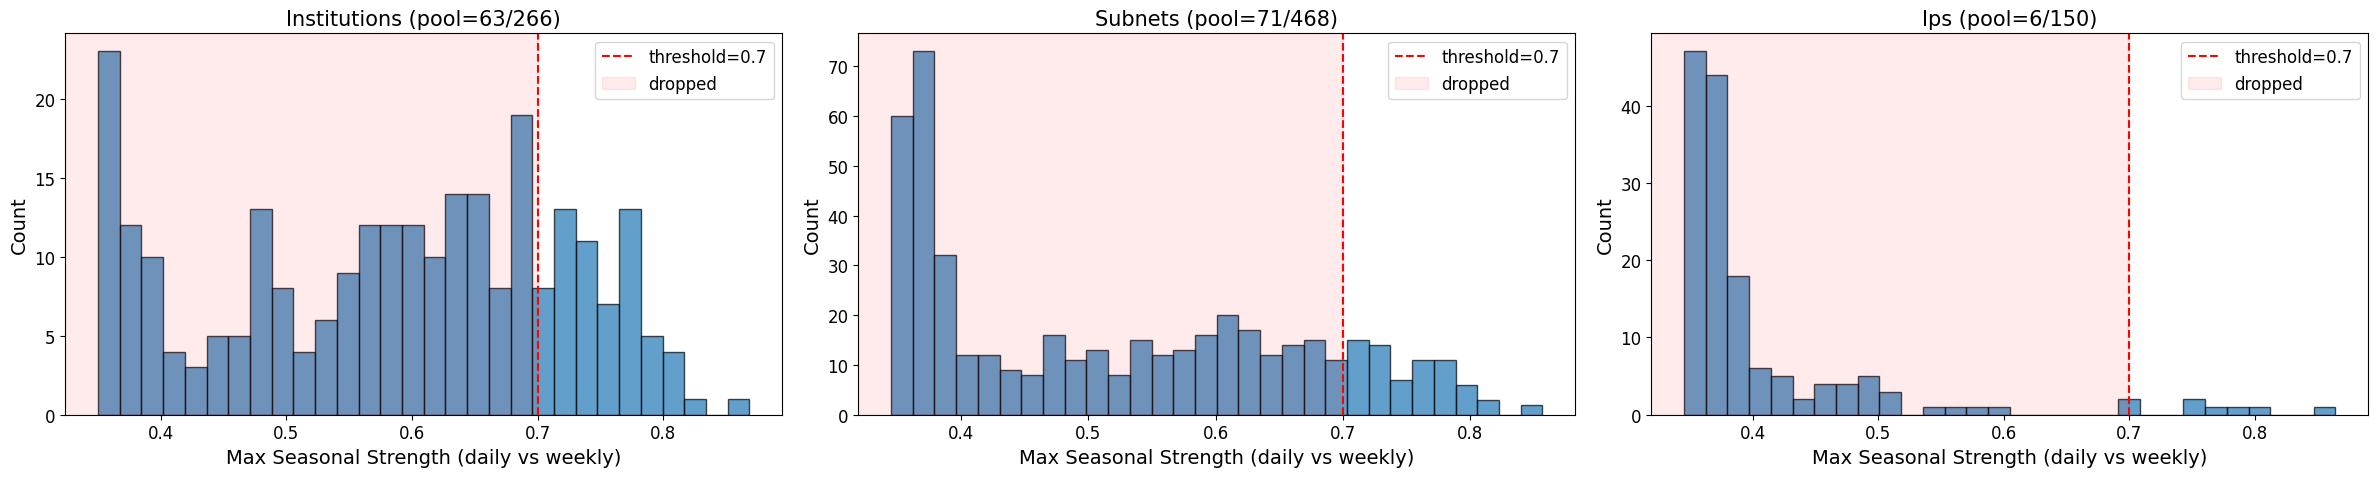

In [3]:
_smin = BENCH_PARAMS["sparsity_min"]
active_scores = {
    s: scores[s][scores[s]["ratio_active"] >= _smin]
    for s in sources
}

plot_pool_distribution(
    [(active_scores[s], s.capitalize()) for s in sources],
    metric_col=BENCH_PARAMS["metric_col"],
    threshold=BENCH_PARAMS["threshold"],
    xlabel="Max Seasonal Strength (daily vs weekly)",
)

## 3 — Selection

Apply sparsity filter, threshold filter, then random sample from the qualifying pool.

In [4]:
selected = {}
pool_sizes = {}

for source in sources:
    ids, pool_size, _ = select_source(BENCHMARK, source, AGGREGATION)
    selected[source] = ids
    pool_sizes[source] = pool_size

print_summary(
    BENCHMARK,
    selected,
    pool_sizes,
    threshold=BENCH_PARAMS["threshold"],
    threshold_name=BENCH_PARAMS["metric_col"],
    sample_size=BENCH_PARAMS["sample_size"],
    seed=RANDOM_SEED,
)

  institutions: 266/283 pass sparsity, pool=63 — selected 25
  subnets: 468/548 pass sparsity, pool=71 — selected 25
  ips: 150/1000 pass sparsity, pool=6 — pool exhausted, taking all 6

SEASON BENCHMARK - Selected Series
Threshold: max_strength >= 0.7
Selection: Random sample of 25 from qualifying pool
Random seed: 42

institutions (25): [0, 7, 9, 10, 12, 15, 23, 39, 41, 48, 50, 53, 63, 95, 100, 102, 127, 147, 161, 175, 186, 206, 216, 228, 240]
  Pool size: 63
subnets (25): [0, 17, 91, 130, 136, 141, 148, 181, 184, 200, 241, 244, 250, 253, 261, 264, 315, 318, 321, 350, 381, 397, 438, 440, 445]
  Pool size: 71
ips (6): [103, 1370, 1845, 10197, 11188, 1951628]
  Pool size: 6


### IP sample pool exhausted — fall back to full IP dataset

In [5]:
path = scores_path(AGGREGATION, BENCHMARK, "ips_full")
if os.path.exists(path):
    print(f"Loading existing scores: {path}")
    scores["ips_full"] = pd.read_csv(path)
else:
    print(f"Computing scores for ips_full (chunked)...")
    scores["ips_full"] = score_source(BENCHMARK, "ips_full", aggregation=AGGREGATION)
scores["ips"] = scores["ips_full"]

print(f"\nips_full: {len(scores['ips_full'])} series scored")
display(scores["ips_full"].describe().round(3))

ids, pool_size, _ = select_source(BENCHMARK, "ips_full", AGGREGATION)
selected["ips"] = ids
pool_sizes["ips"] = pool_size

print(f"\nips selected from full dataset ({len(ids)}): {ids}")
print(f"Pool size: {pool_size}")

Loading existing scores: scores/10min/SEASON_ips_full.csv

ips_full: 275124 series scored


,id_ip,ratio_active,strength_daily,strength_weekly,max_strength
count,275124.000,275124.000,34729.000,34729.000,34729.000
mean,883801.658,0.150,0.380,0.392,0.395
std,666745.924,0.236,0.069,0.076,0.078
min,3.000,0.000,0.238,0.224,0.295
25%,293947.500,0.019,0.349,0.358,0.359
50%,650919.500,0.051,0.355,0.365,0.366
75%,1623585.000,0.138,0.374,0.384,0.385
max,2055783.000,1.000,0.970,0.962,0.970


  ips_full: 34729/275124 pass sparsity, pool=548 — selected 25

ips selected from full dataset (25): [83, 2938, 3052, 3135, 4729, 4897, 15032, 17447, 17669, 18214, 26685, 36509, 38586, 40138, 53602, 77052, 78489, 99092, 122315, 186070, 204405, 349693, 435318, 747744, 1544688]
Pool size: 548


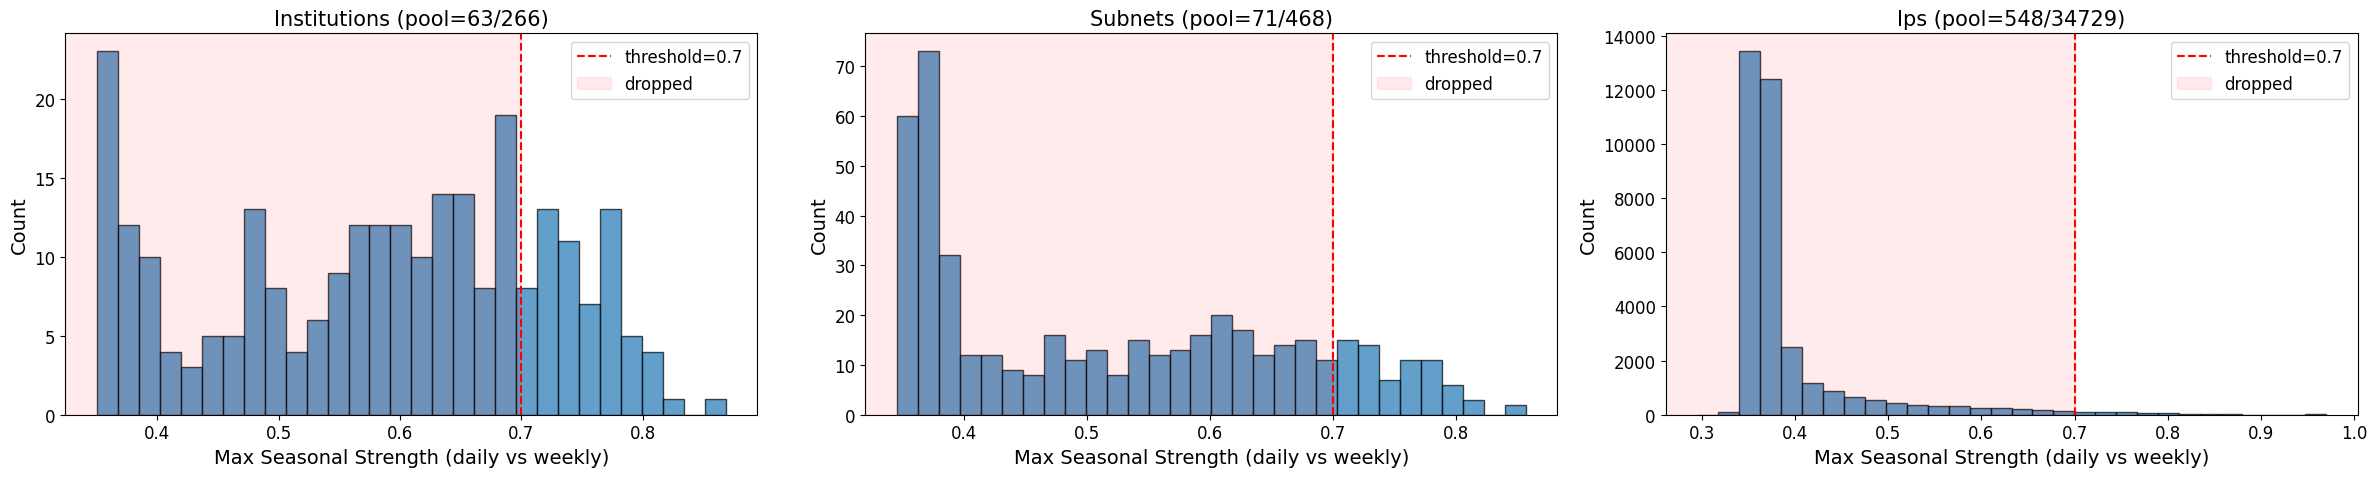

In [6]:
active_scores = {
    s: scores[s][scores[s]["ratio_active"] >= _smin]
    for s in sources
}

plot_pool_distribution(
    [(active_scores[s], s.capitalize()) for s in sources],
    metric_col=BENCH_PARAMS["metric_col"],
    threshold=BENCH_PARAMS["threshold"],
    xlabel="Max Seasonal Strength (daily vs weekly)",
)

## 4 — Detailed scores for selected series

In [7]:
for source in sources:
    _, id_col = SOURCE_MAP[source]
    df_s = scores.get("ips_full") if source == "ips" and "ips_full" in scores else scores[source]
    sel = df_s[df_s[id_col].isin(selected[source])].sort_values("max_strength", ascending=False)
    print(f"\n{source.capitalize()} — selected series scores:")
    display(sel)


Institutions — selected series scores:


,id_institution,ratio_active,strength_daily,strength_weekly,max_strength
58,0.0,1.000000,0.868578,0.850132,0.868578
36,7.0,0.997246,0.716450,0.799819,0.799819
106,50.0,1.000000,0.774531,0.797597,0.797597
206,53.0,0.999950,0.784430,0.770659,0.784430
43,63.0,0.999975,0.715765,0.781278,0.781278
254,127.0,0.999429,0.701682,0.779671,0.779671
191,10.0,1.000000,0.635239,0.778647,0.778647
125,23.0,1.000000,0.754895,0.774480,0.774480
199,39.0,0.998263,0.528956,0.774078,0.774078
62,147.0,1.000000,0.680766,0.767810,0.767810



Subnets — selected series scores:


,id_institution_subnet,ratio_active,strength_daily,strength_weekly,max_strength
491,0.0,0.999950,0.856547,0.839393,0.856547
411,181.0,1.000000,0.731124,0.807822,0.807822
195,321.0,0.998114,0.704949,0.795926,0.795926
492,397.0,0.997618,0.713309,0.783093,0.783093
135,445.0,0.999851,0.672582,0.782494,0.782494
441,264.0,1.000000,0.653826,0.781013,0.781013
29,350.0,0.999429,0.701682,0.779671,0.779671
160,253.0,0.999603,0.712027,0.778912,0.778912
536,91.0,0.998412,0.768180,0.758931,0.768180
386,130.0,0.996873,0.681748,0.766523,0.766523



Ips — selected series scores:


,id_ip,ratio_active,strength_daily,strength_weekly,max_strength
168879,122315.0,0.999926,0.901019,0.868675,0.901019
14982,53602.0,0.795002,0.819053,0.819578,0.819578
11611,40138.0,0.987171,0.788955,0.801416,0.801416
998,2938.0,1.000000,0.748646,0.796236,0.796236
78656,1544688.0,0.774455,0.791821,0.784070,0.791821
10647,36509.0,0.436970,0.703254,0.788214,0.788214
1556,4729.0,0.997965,0.725518,0.782908,0.782908
187029,204405.0,0.453968,0.458184,0.779193,0.779193
217801,349693.0,0.599831,0.701337,0.775998,0.775998
1612,4897.0,0.999702,0.765845,0.596458,0.765845


## 5 — Verification plots

For a few selected series per level: raw time series, STL decomposition, and ACF.

In [8]:
def plot_stl_verification(df, id_col, ts_id, agg_params):
    grp = df[df[id_col] == ts_id].reset_index(drop=True)
    t = grp["datetime"]
    y_log = np.log1p(grp["n_bytes"].astype(float))

    s_daily = seasonality_strength(y_log, agg_params["daily_period"])
    s_weekly = seasonality_strength(y_log, agg_params["weekly_period"])
    best_period = agg_params["daily_period"] if s_daily >= s_weekly else agg_params["weekly_period"]
    period_hours = best_period * STEP_MINUTES / 60
    period_label = f'daily ({period_hours:.0f}h)' if best_period == agg_params["daily_period"] else f'weekly ({period_hours:.0f}h)'
    stl = STL(y_log, period=best_period).fit()

    components = [
        ('Observed — log1p(n_bytes)', y_log.values, '#1f77b4'),
        ('Trend', stl.trend.values, '#2ca02c'),
        (f'Seasonal (period={period_label})', stl.seasonal.values, '#9467bd'),
        ('Residual', stl.resid.values, '#d62728'),
    ]

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    for ax, (title, vals, color) in zip(axes, components):
        ax.plot(t, vals, linewidth=0.5, color=color)
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3)

    axes[0].set_title(
        f'{id_col}={int(ts_id)}  —  seasonal strength: daily={s_daily:.3f}, weekly={s_weekly:.3f}'
    )
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

100%|████████████████████████████| 3/3 [00:07<00:00,  2.59s/it]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.INSTITUTIONS

    Time series
        Time series IDS: [127   9 161], Length=3
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test batch size: 128


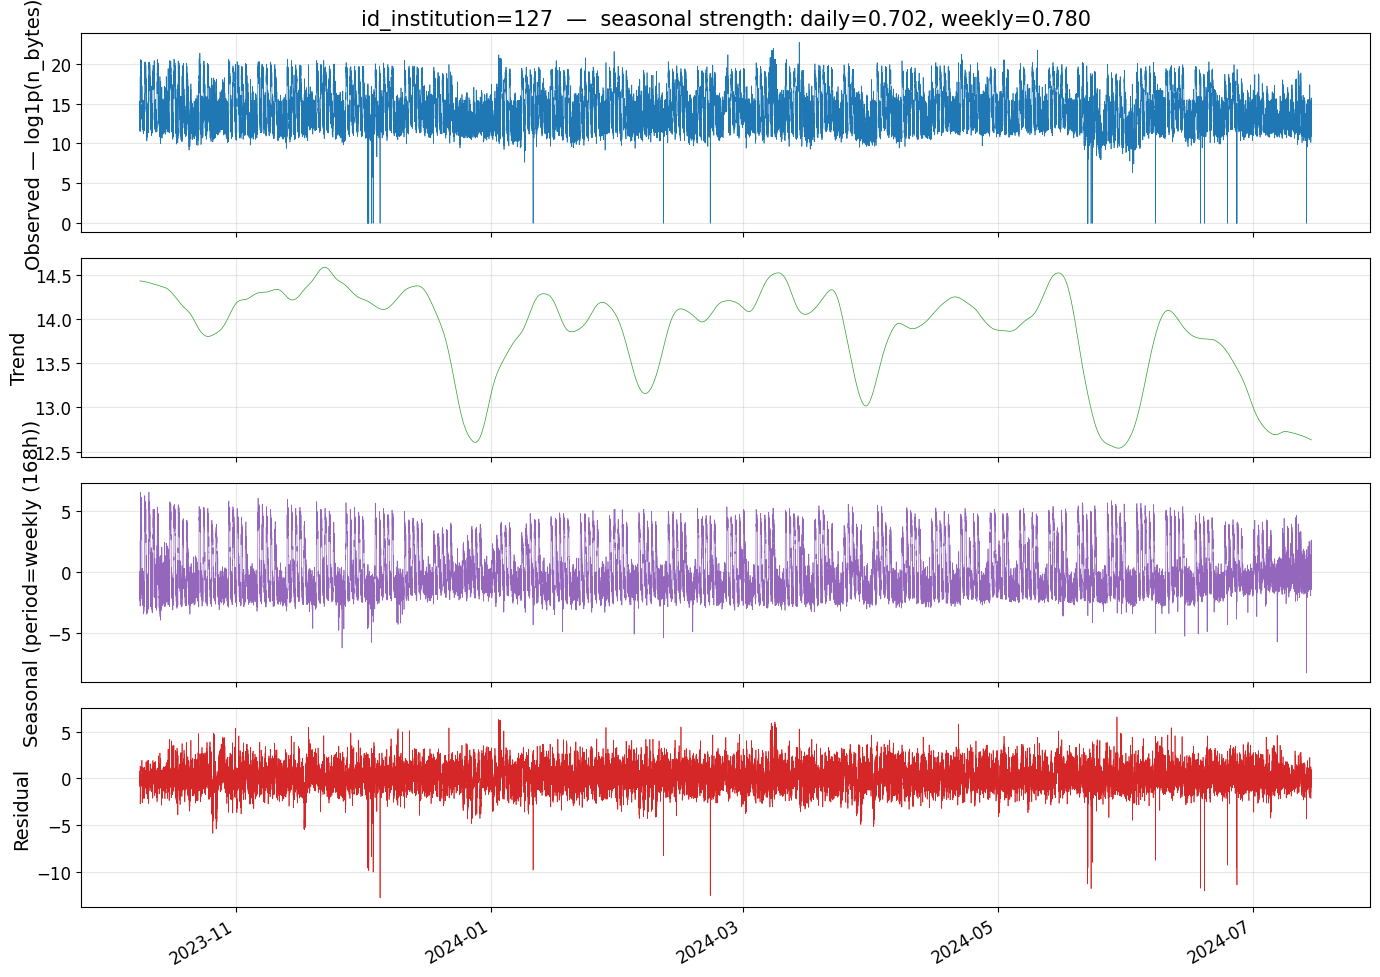

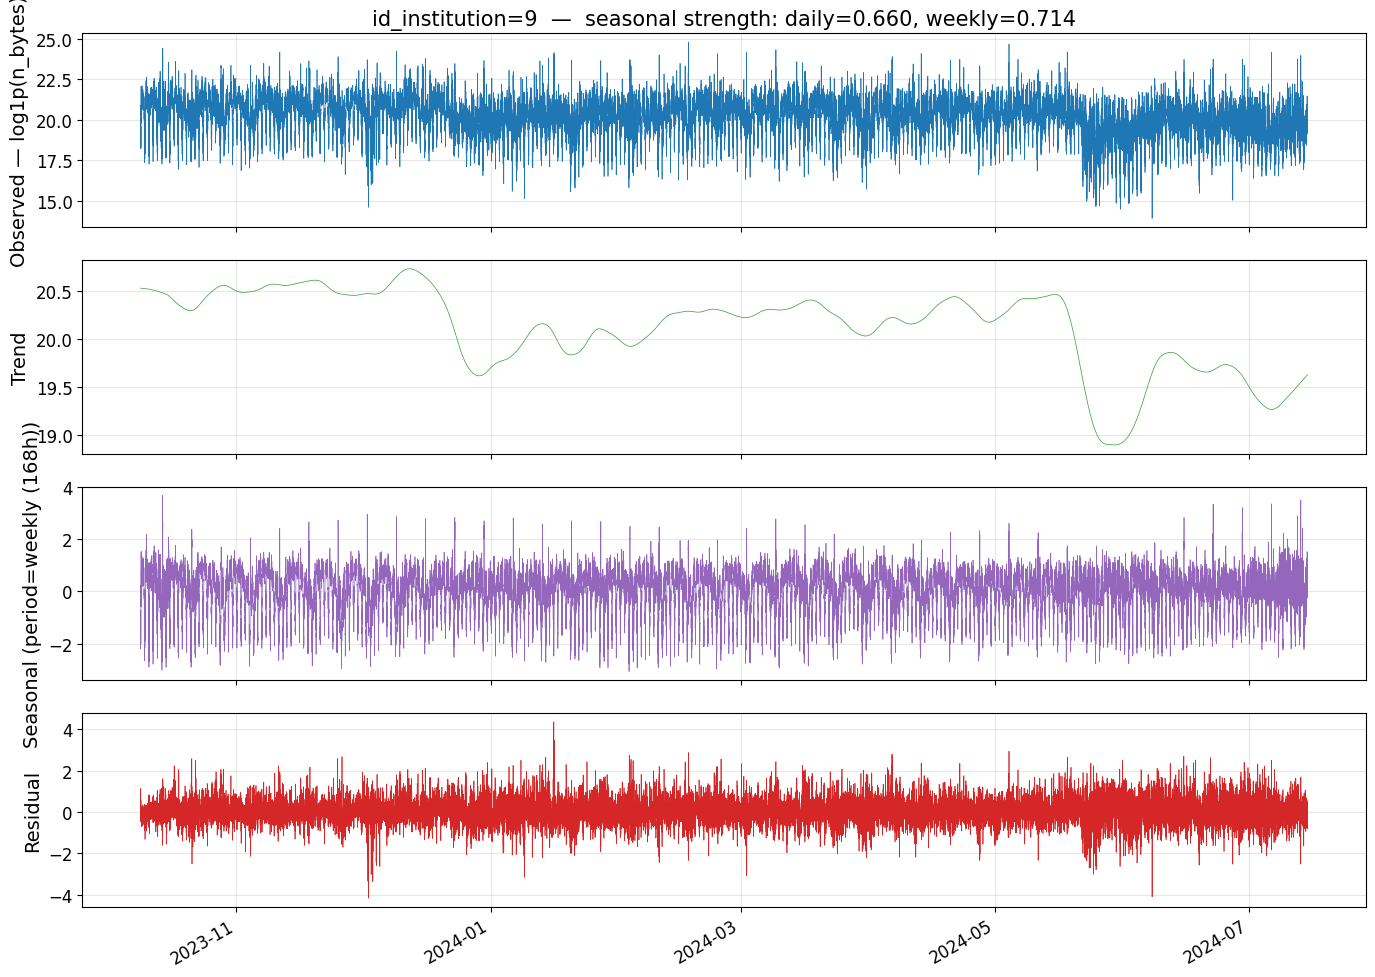

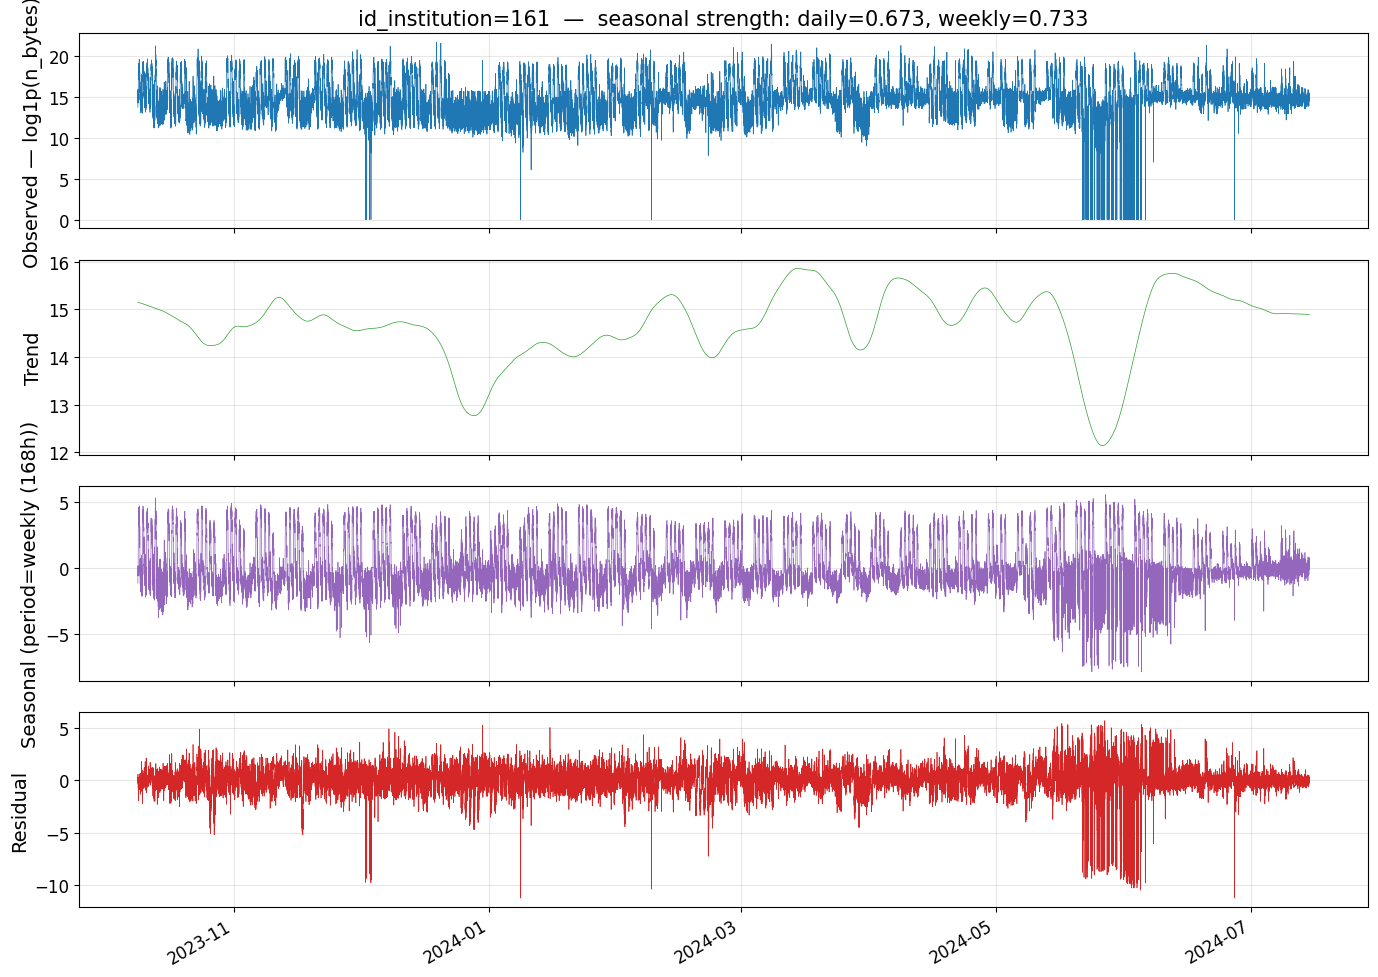

100%|████████████████████████████| 3/3 [00:08<00:00,  2.82s/it]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.INSTITUTION_SUBNETS

    Time series
        Time series IDS: [ 91 318 350], Length=3
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test batch siz

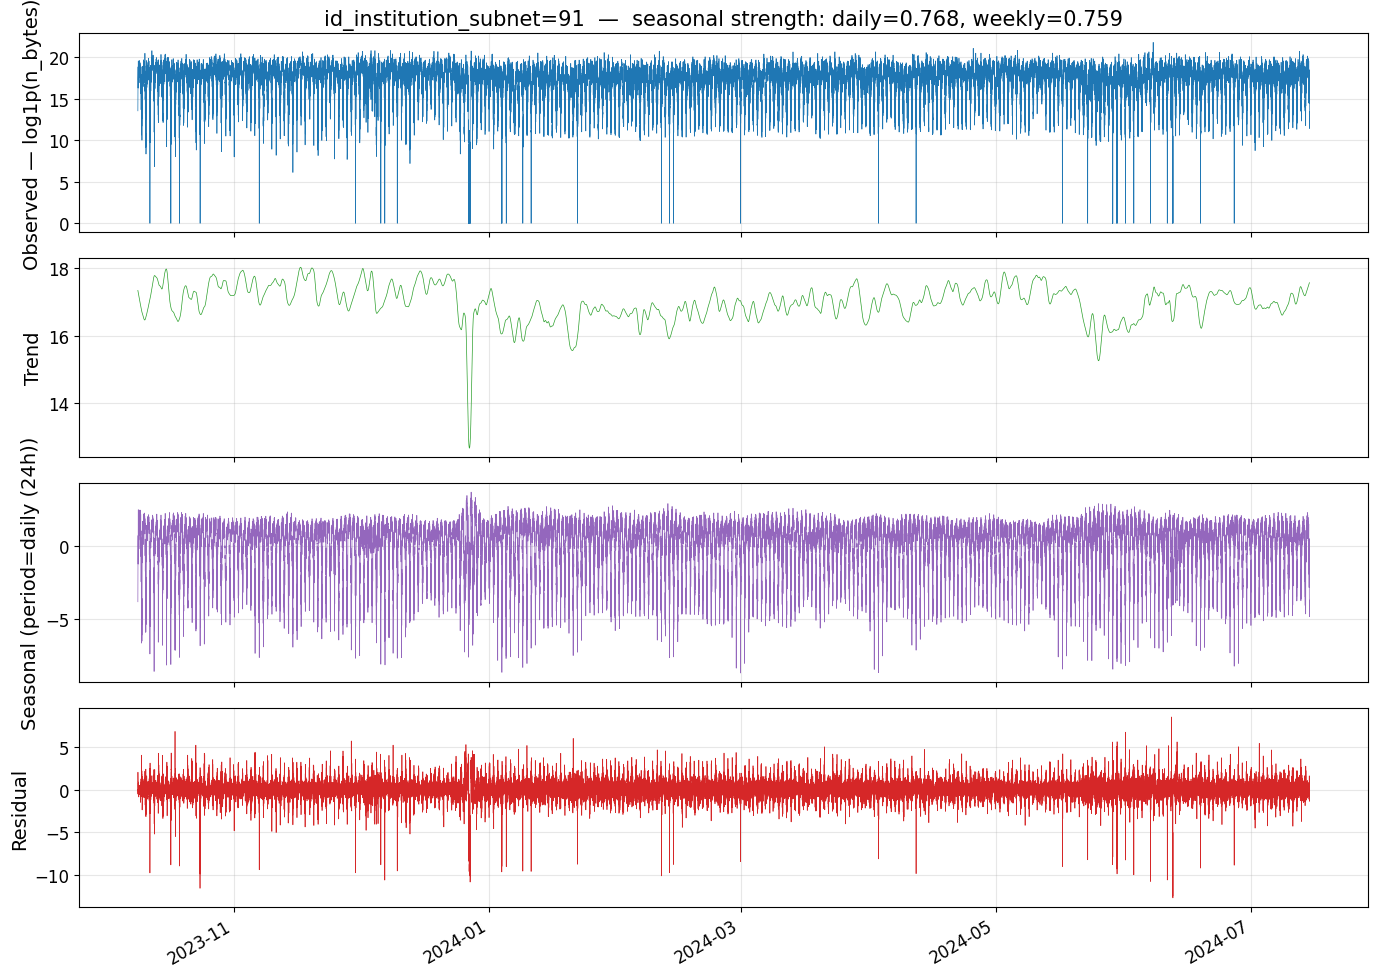

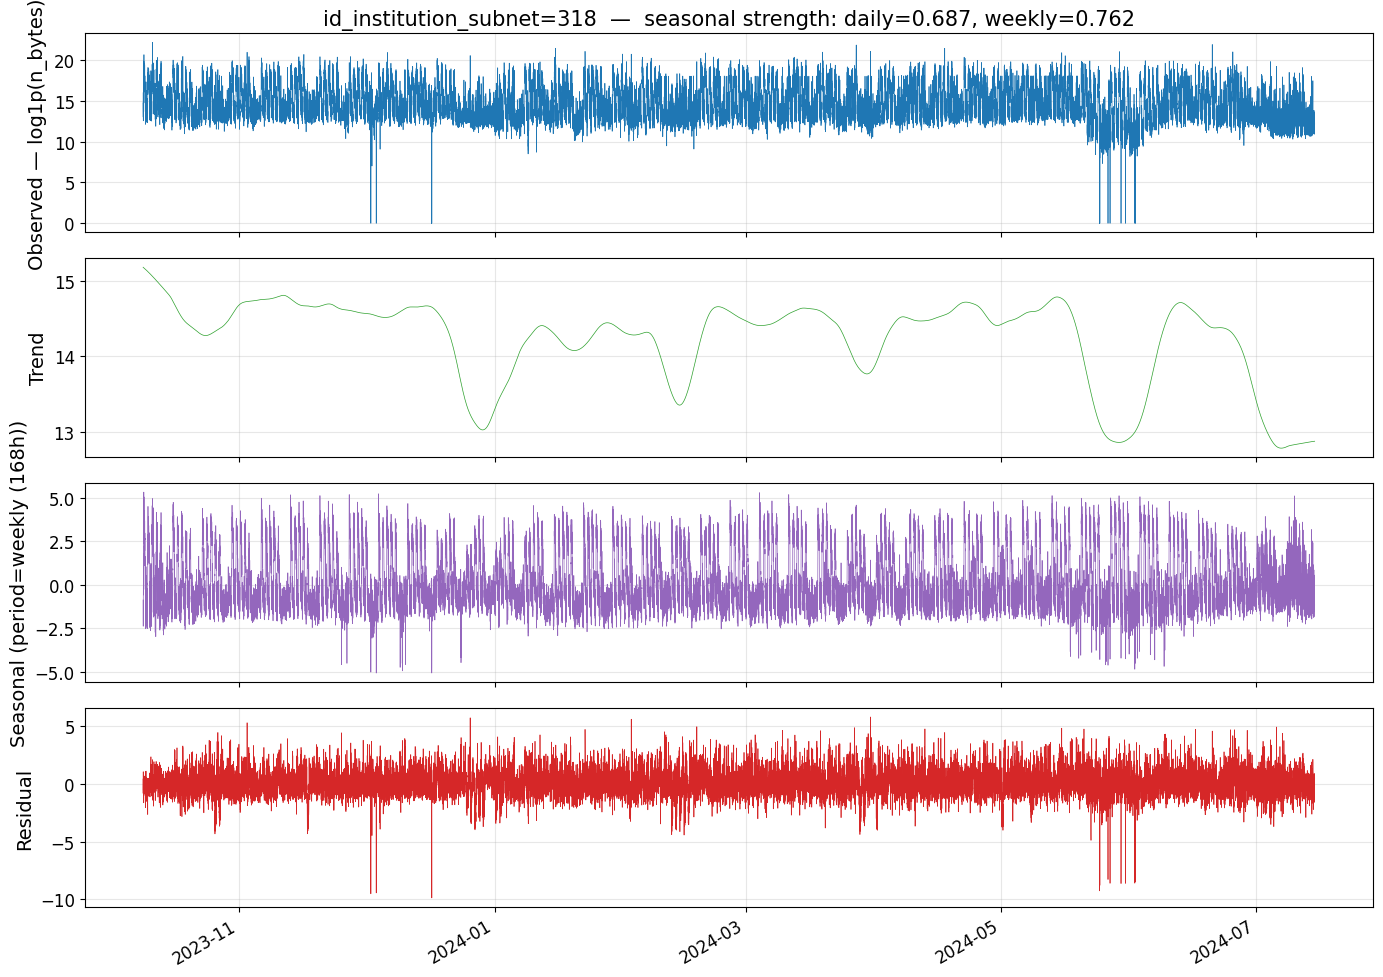

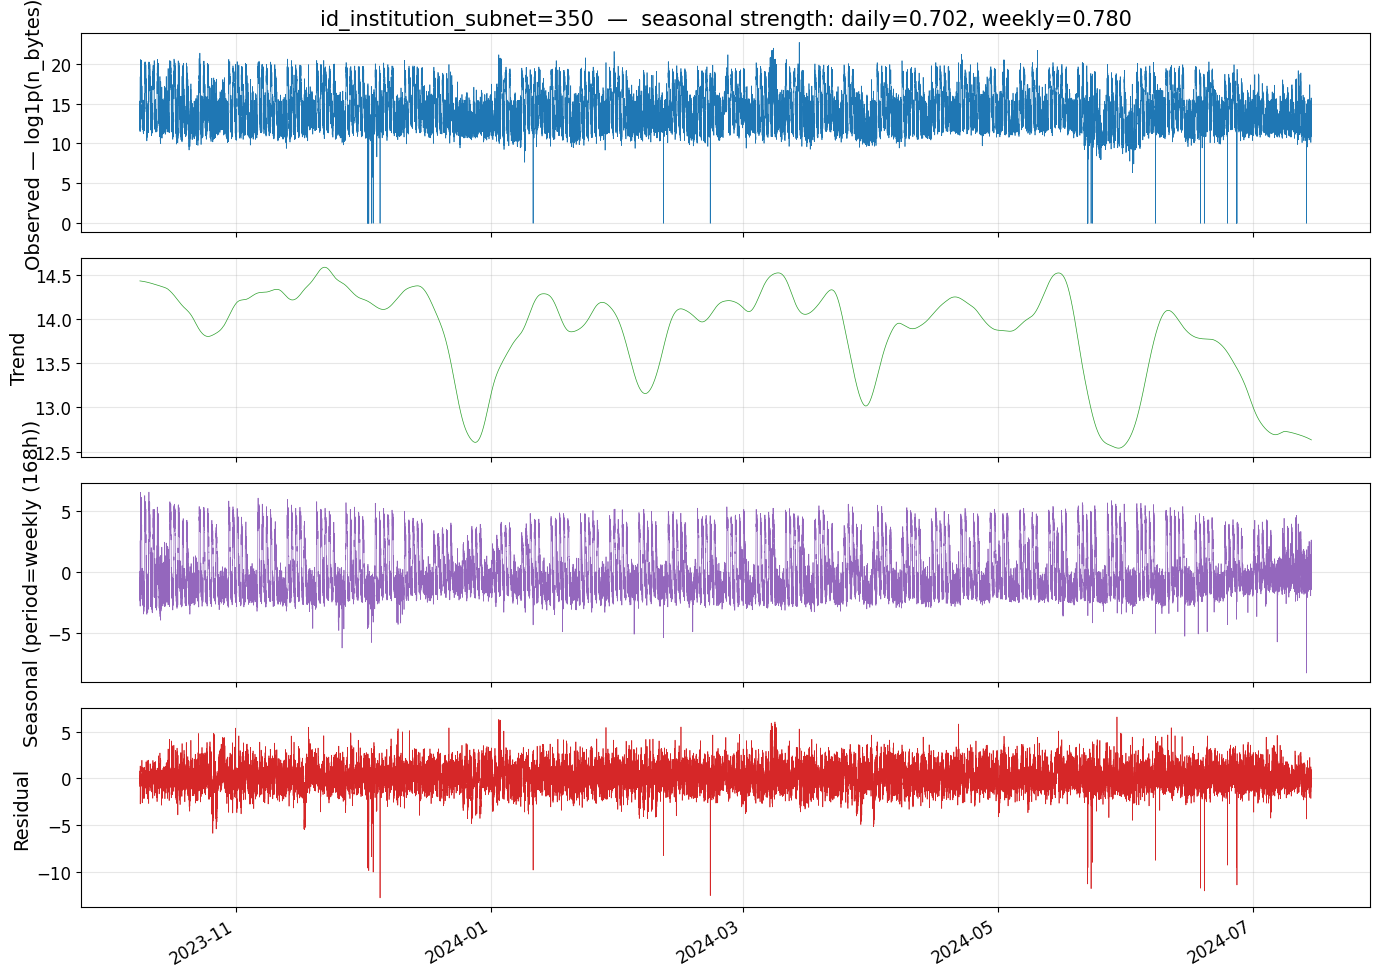

100%|████████████████████████████| 3/3 [00:07<00:00,  2.56s/it]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.IP_ADDRESSES_FULL

    Time series
        Time series IDS: [ 38586 747744 122315], Length=3
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test ba

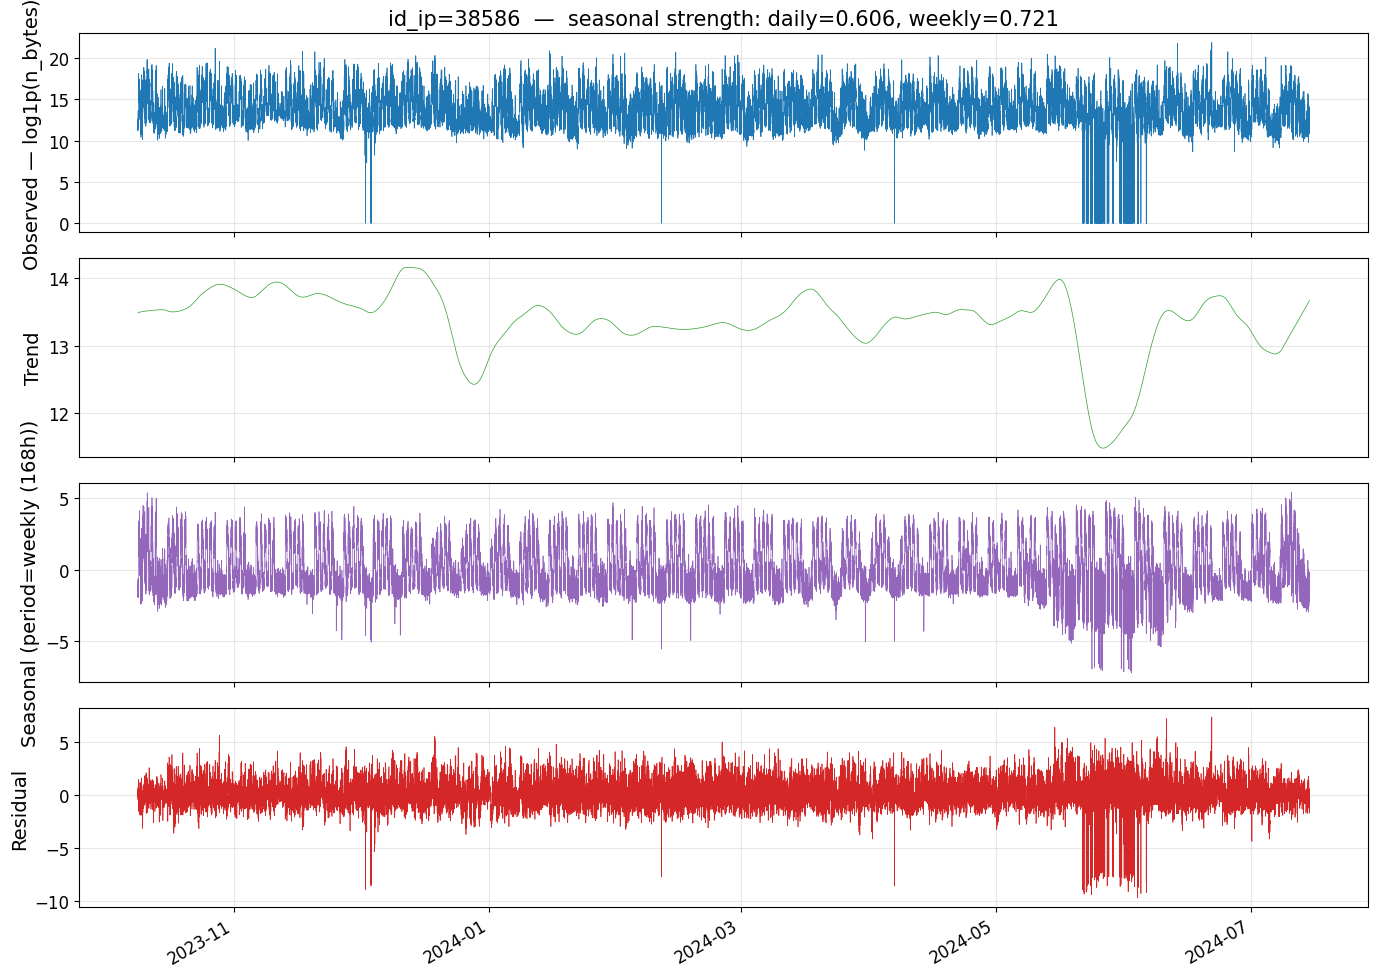

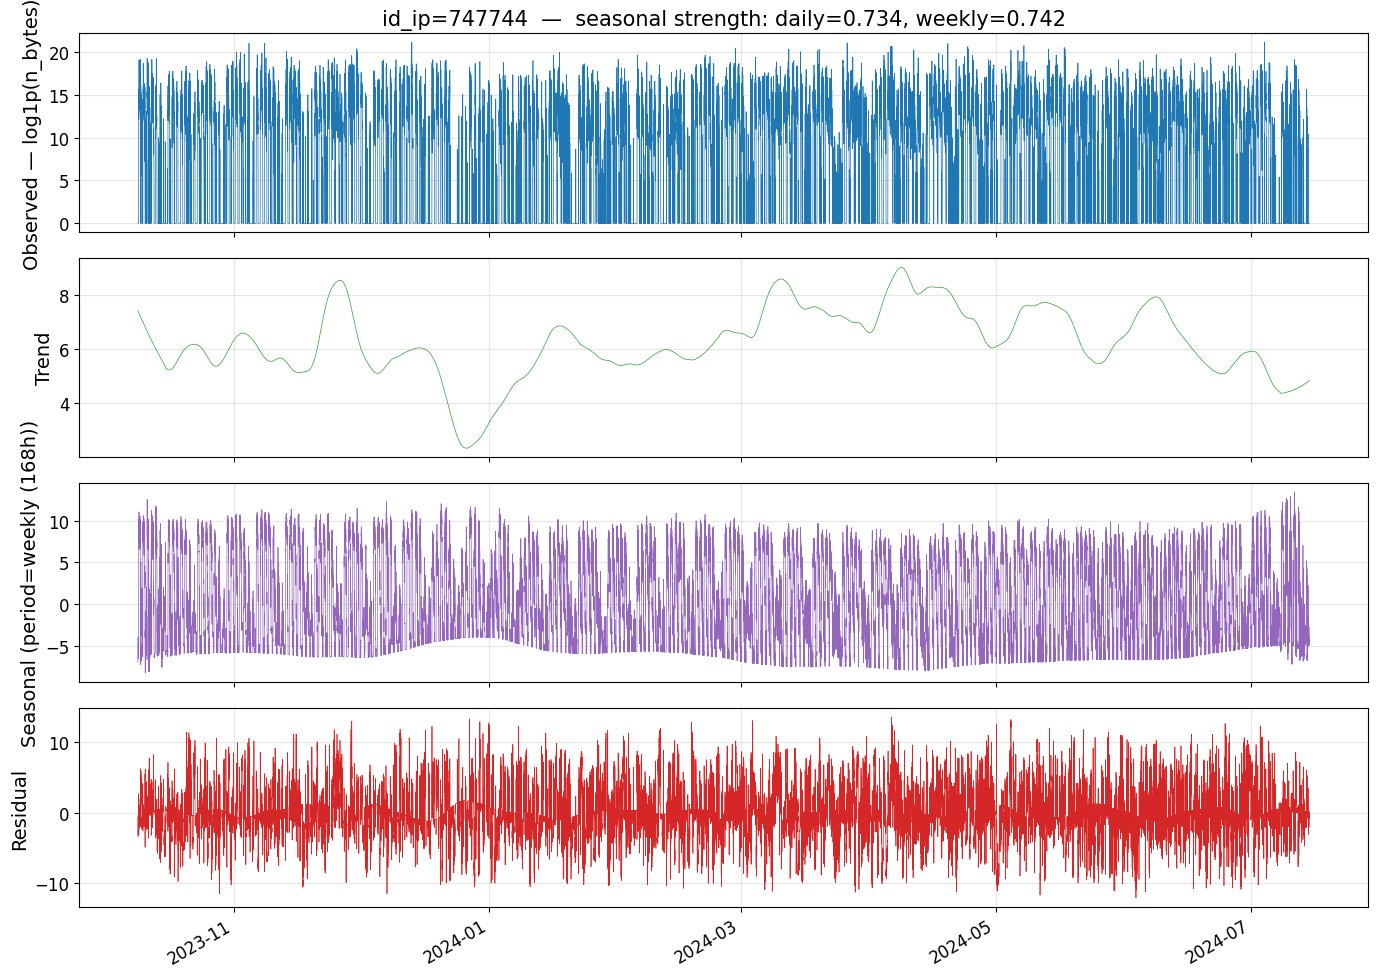

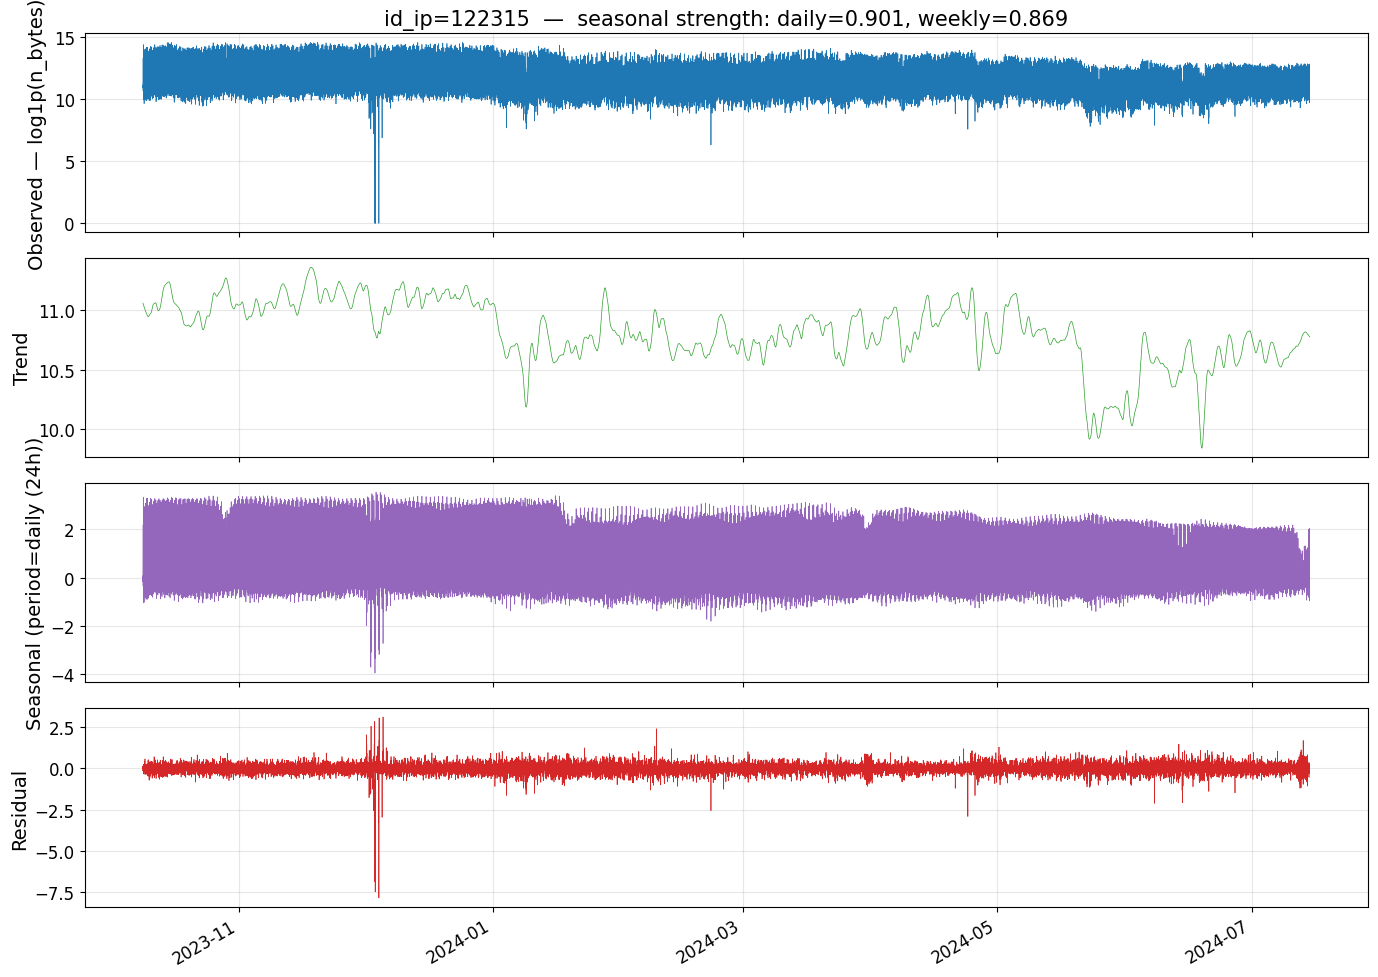

In [9]:
N_VERIFY = 3
rng = np.random.default_rng(RANDOM_SEED)

for source in sources:
    _, id_col = SOURCE_MAP[source]
    verify_ids = rng.choice(selected[source], size=min(N_VERIFY, len(selected[source])), replace=False).tolist()
    load_source = "ips_full" if source == "ips" and "ips_full" in scores else source
    data = load_dataset(load_source, aggregation=AGG_PARAMS["enum"], time_range=AGG_PARAMS["time_range"], ts_ids=verify_ids)
    df = data["df"]
    print(f"\n{'='*60}")
    print(f"{source.upper()} — verifying {len(verify_ids)} series")
    print(f"{'='*60}")
    for ts_id in verify_ids:
        plot_stl_verification(df, id_col, ts_id, AGG_PARAMS)

## 6 — Save selection

In [10]:
save_selection(selected, BENCHMARK, AGGREGATION)

Saved selected_ids/10min/SEASON.csv (75 series)


'selected_ids/10min/SEASON.csv'